# Tiny Dataset Working Demo — All Models

This notebook shows a small working example of the full pipeline using a tiny real subset of the BraTS2020 dataset.

The purpose is to demonstrate that the complete pipeline runs end-to-end, including data loading, preprocessing, model input, training, evaluation, and visualization.

This notebook is not intended for final accuracy evaluation.

**1.Imports**

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


**2 Required Package Installation**

In [ ]:
!pip install nibabel gdown -q

**3.Import Dataset Loading**

In [ ]:
import os, glob, zipfile, gdown
import nibabel as nib

**4.Download and Extract Tiny BraTS Dataset**

In [ ]:
FILE_ID = "17hNsEKtSs25jjfOAqUZuENXx61EAxG-U"
url = f"https://drive.google.com/uc?id={FILE_ID}"

zip_path = "tiny_brats_demo.zip"
extract_dir = "tiny_brats_demo"

if not os.path.exists(extract_dir):
    gdown.download(url, zip_path, quiet=False)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Tiny dataset downloaded and extracted.")
else:
    print("Tiny dataset already exists.")

Tiny dataset already exists.


**5.Locate Tiny Dataset Patient Folders**

In [ ]:
DATA_DIR = "tiny_brats_demo"

patient_dirs = sorted(glob.glob(os.path.join(DATA_DIR, "BraTS20_Training_*")))

print("Number of patients:", len(patient_dirs))
print(patient_dirs[:3])

Number of patients: 3
['tiny_brats_demo/BraTS20_Training_001', 'tiny_brats_demo/BraTS20_Training_002', 'tiny_brats_demo/BraTS20_Training_003']


**6.Define Dataset Configuration**

In [ ]:
CLASS_NAMES = ["NCR/NET", "ED", "ET"]
NUM_CLASSES = 3
NUM_SLICES = 5
IMG_SIZE = 128
BATCH_SIZE = 1
EPOCHS = 1

**7.Normalize MRI Image Intensities**

In [ ]:
def normalize_img(img):
    img = img.astype(np.float32)
    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())
    return img

**8.Resize MRI Slices**

In [ ]:
def center_crop_or_resize(slice_2d, size=128):
    tensor = torch.tensor(slice_2d, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    tensor = torch.nn.functional.interpolate(
        tensor, size=(size, size), mode="bilinear", align_corners=False
    )
    return tensor.squeeze().numpy()

**9.Load Patient MRI Modalities and Tumor Labels**

In [ ]:
def load_patient(patient_dir):
    flair_path = glob.glob(os.path.join(patient_dir, "*flair.nii"))[0]
    t1_path    = glob.glob(os.path.join(patient_dir, "*t1.nii"))[0]
    t1ce_path  = glob.glob(os.path.join(patient_dir, "*t1ce.nii"))[0]
    t2_path    = glob.glob(os.path.join(patient_dir, "*t2.nii"))[0]
    seg_path   = glob.glob(os.path.join(patient_dir, "*seg.nii"))[0]

    flair = normalize_img(nib.load(flair_path).get_fdata())
    t1    = normalize_img(nib.load(t1_path).get_fdata())
    t1ce  = normalize_img(nib.load(t1ce_path).get_fdata())
    t2    = normalize_img(nib.load(t2_path).get_fdata())
    seg   = nib.load(seg_path).get_fdata()

    tumor_slices = np.where(seg.sum(axis=(0, 1)) > 0)[0]

    if len(tumor_slices) >= NUM_SLICES:
        mid = len(tumor_slices) // 2
        selected = tumor_slices[max(0, mid - NUM_SLICES // 2): max(0, mid - NUM_SLICES // 2) + NUM_SLICES]
    else:
        center = seg.shape[2] // 2
        selected = np.arange(center - NUM_SLICES // 2, center + NUM_SLICES // 2 + 1)[:NUM_SLICES]

    slices = []

    for s in selected:
        four_channel = np.stack([
            center_crop_or_resize(flair[:, :, s], IMG_SIZE),
            center_crop_or_resize(t1[:, :, s], IMG_SIZE),
            center_crop_or_resize(t1ce[:, :, s], IMG_SIZE),
            center_crop_or_resize(t2[:, :, s], IMG_SIZE)
        ], axis=0)

        slices.append(four_channel)

    volume = np.stack(slices, axis=0)

    label = np.array([
        np.any(seg == 1),  # NCR/NET
        np.any(seg == 2),  # ED
        np.any(seg == 4)   # ET
    ], dtype=np.float32)

    return volume, label

**10.Load Tiny Dataset into NumPy Arrays**

In [ ]:
all_images = []
all_labels = []
all_patient_ids = []

for patient_dir in patient_dirs:
    volume, label = load_patient(patient_dir)
    all_images.append(volume)
    all_labels.append(label)
    all_patient_ids.append(os.path.basename(patient_dir))

all_images = np.array(all_images, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.float32)

print("Images shape:", all_images.shape)
print("Labels shape:", all_labels.shape)

pd.DataFrame(all_labels, columns=CLASS_NAMES, index=all_patient_ids)

Images shape: (3, 5, 4, 128, 128)
Labels shape: (3, 3)


,NCR/NET,ED,ET
BraTS20_Training_001,1.0,1.0,1.0
BraTS20_Training_002,1.0,1.0,1.0
BraTS20_Training_003,1.0,1.0,1.0


**11.Visualize Sample BraTS MRI Modalities**

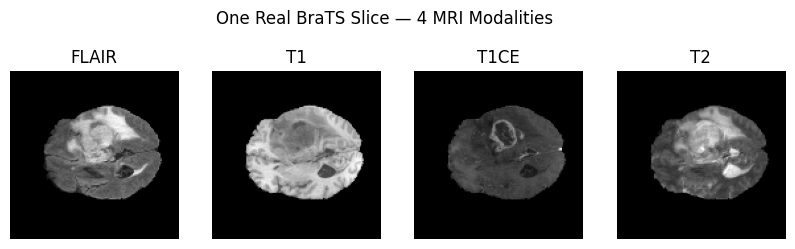

In [ ]:
sample = all_images[0, 0]

plt.figure(figsize=(10, 3))

for i, name in enumerate(["FLAIR", "T1", "T1CE", "T2"]):
    plt.subplot(1, 4, i + 1)
    plt.imshow(sample[i], cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.suptitle("One Real BraTS Slice — 4 MRI Modalities")
plt.show()

**12.Create PyTorch Dataset and DataLoader**

In [ ]:
class TinyBraTSDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


dataset = TinyBraTSDataset(all_images, all_labels)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

for x, y in loader:
    print("Batch image shape:", x.shape)
    print("Batch label shape:", y.shape)
    break

Batch image shape: torch.Size([1, 5, 4, 128, 128])
Batch label shape: torch.Size([1, 3])


**13. Define Demo Model Architectures**

In [ ]:
class EfficientNetStyleDemo(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.mean(dim=1)
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


class ViTStyleDemo(nn.Module):
    def __init__(self, num_classes=3, img_size=128, patch_size=16, embed_dim=64):
        super().__init__()
        self.patch_embed = nn.Conv2d(4, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = x.mean(dim=1)
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.classifier(x)


class SwinStyleDemo(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=4, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.mean(dim=1)
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


class SwinMILDemo(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.slice_encoder = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=4, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.attention = nn.Sequential(
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        features = self.slice_encoder(x)
        features = features.flatten(1)
        features = features.view(B, S, -1)

        attention_scores = self.attention(features)
        attention_weights = torch.softmax(attention_scores, dim=1)

        patient_feature = (features * attention_weights).sum(dim=1)
        return self.classifier(patient_feature)

**14. Define Training and Evaluation Pipeline**

In [ ]:
def train_and_evaluate(model, loader, model_name):
    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses = []

    model.train()

    for epoch in range(EPOCHS):
        epoch_loss = 0.0

        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)

        print(f"{model_name} | Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

    model.eval()

    all_probs = []
    all_preds = []
    all_true = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)

            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)

            all_probs.append(probs)
            all_preds.append(preds)
            all_true.append(labels.numpy())

    all_probs = np.vstack(all_probs)
    all_preds = np.vstack(all_preds)
    all_true = np.vstack(all_true)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(all_true.flatten(), all_preds.flatten()),
        "precision_macro": precision_score(all_true, all_preds, average="macro", zero_division=0),
        "recall_macro": recall_score(all_true, all_preds, average="macro", zero_division=0),
        "f1_macro": f1_score(all_true, all_preds, average="macro", zero_division=0),
        "loss": train_losses[-1]
    }

    per_label = {}

    for i, label_name in enumerate(CLASS_NAMES):
        per_label[label_name] = {
            "precision": precision_score(all_true[:, i], all_preds[:, i], zero_division=0),
            "recall": recall_score(all_true[:, i], all_preds[:, i], zero_division=0),
            "f1": f1_score(all_true[:, i], all_preds[:, i], zero_division=0),
            "accuracy": accuracy_score(all_true[:, i], all_preds[:, i])
        }

    per_label_df = pd.DataFrame(per_label).T

    return metrics, per_label_df, train_losses, all_probs, all_preds, all_true

**15. Train and Evaluate All Four Models**

In [ ]:
models = {
    "EfficientNet-style CNN": EfficientNetStyleDemo(NUM_CLASSES),
    "ViT-style Transformer": ViTStyleDemo(NUM_CLASSES, img_size=IMG_SIZE),
    "Swin-style Transformer": SwinStyleDemo(NUM_CLASSES),
    "Swin + MIL": SwinMILDemo(NUM_CLASSES)
}

all_metrics = []
all_per_label = {}
all_losses = {}

for model_name, model in models.items():
    print("\n==============================")
    print("Running:", model_name)
    print("==============================")

    metrics, per_label_df, losses, probs, preds, true_labels = train_and_evaluate(
        model, loader, model_name
    )

    all_metrics.append(metrics)
    all_per_label[model_name] = per_label_df
    all_losses[model_name] = losses

metrics_df = pd.DataFrame(all_metrics)
metrics_df


Running: EfficientNet-style CNN
EfficientNet-style CNN | Epoch 1/1 | Loss: 0.6596

Running: ViT-style Transformer
ViT-style Transformer | Epoch 1/1 | Loss: 0.2689

Running: Swin-style Transformer
Swin-style Transformer | Epoch 1/1 | Loss: 0.6657

Running: Swin + MIL
Swin + MIL | Epoch 1/1 | Loss: 0.7097


,model,accuracy,precision_macro,recall_macro,f1_macro,loss
0,EfficientNet-style CNN,0.666667,0.666667,0.666667,0.666667,0.659630
1,ViT-style Transformer,1.000000,1.000000,1.000000,1.000000,0.268851
2,Swin-style Transformer,1.000000,1.000000,1.000000,1.000000,0.665720
3,Swin + MIL,0.333333,0.333333,0.333333,0.333333,0.709654


**16. Display Per-Label Tumor Region Metrics**

In [ ]:
for model_name, df in all_per_label.items():
    print("\n", model_name)
    display(df.round(4))


 EfficientNet-style CNN


,precision,recall,f1,accuracy
NCR/NET,1.0,1.0,1.0,1.0
ED,0.0,0.0,0.0,0.0
ET,1.0,1.0,1.0,1.0



 ViT-style Transformer


,precision,recall,f1,accuracy
NCR/NET,1.0,1.0,1.0,1.0
ED,1.0,1.0,1.0,1.0
ET,1.0,1.0,1.0,1.0



 Swin-style Transformer


,precision,recall,f1,accuracy
NCR/NET,1.0,1.0,1.0,1.0
ED,1.0,1.0,1.0,1.0
ET,1.0,1.0,1.0,1.0



 Swin + MIL


,precision,recall,f1,accuracy
NCR/NET,0.0,0.0,0.0,0.0
ED,1.0,1.0,1.0,1.0
ET,0.0,0.0,0.0,0.0


**17. Plot Macro F1-Score Comparison**

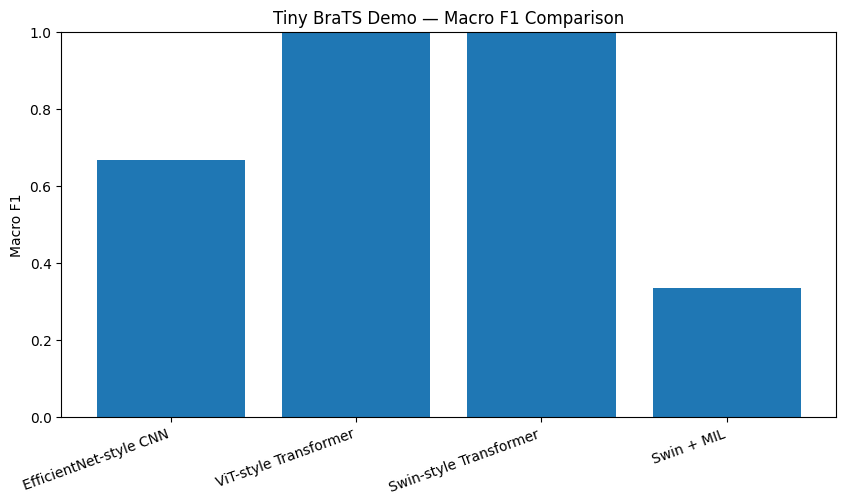

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(metrics_df["model"], metrics_df["f1_macro"])
plt.ylabel("Macro F1")
plt.title("Tiny BraTS Demo — Macro F1 Comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.show()

**18. Plot Training Loss Comparison**

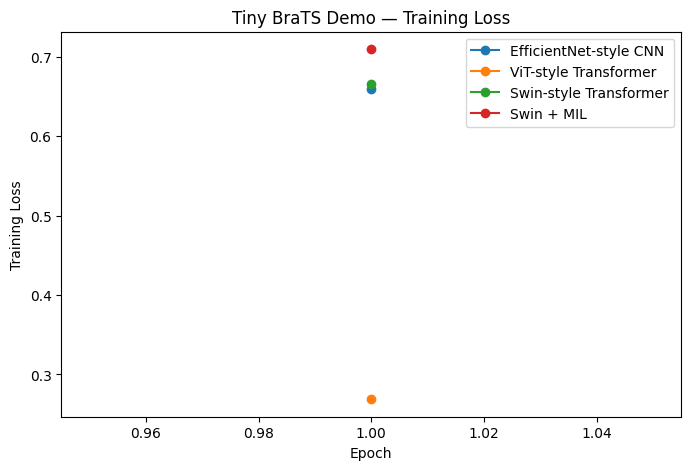

In [ ]:
plt.figure(figsize=(8, 5))

for model_name, losses in all_losses.items():
    plt.plot(range(1, len(losses) + 1), losses, marker="o", label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Tiny BraTS Demo — Training Loss")
plt.legend()
plt.show()